In [1]:
import pandas as pd
import seaborn as sns

In [2]:
data = pd.read_csv("BostonHousing.csv")

In [3]:
data.isnull().sum()

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            5
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

In [4]:
data['rm'] = data['rm'].fillna(data['rm'].mean())

In [5]:
data.head()

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


<Axes: >

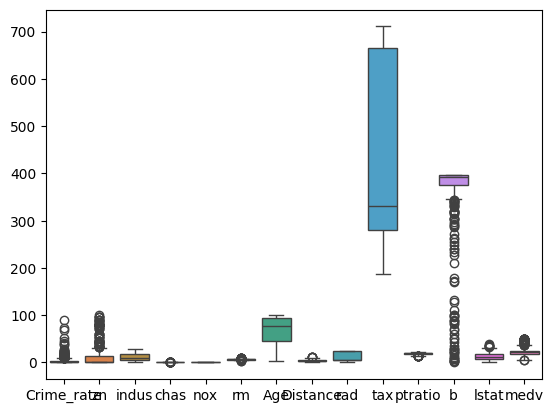

In [6]:
sns.boxplot(data=data)

In [7]:
def outliers(col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3-q1

    lower = q1-1.5*iqr
    upper = q3+1.5*iqr
    for i in range(0, len(data[col])):
        if data[col][i] < lower:
            data[col][i] = lower
        if data[col][i] > upper:
            data[col][i] = upper

for i in data:
    outliers(i)

C:\Users\Shreyash Nathe\AppData\Local\Temp\ipykernel_32304\3375184953.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col][i] = upper
C:\Users\Shreyash Nathe\AppData\Local\Temp\ipykernel_32304\3375184953.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col][i] = upper
C:\Users\Shreyash Nathe\AppData\Local\Temp\ipykernel_32304\3375184953.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col][i] = upper
C:\User

<Axes: >

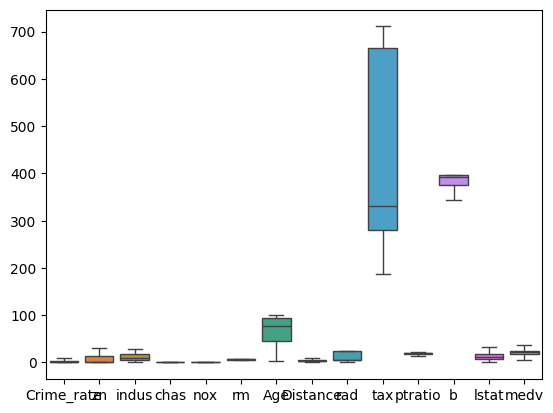

In [8]:
sns.boxplot(data=data)

In [9]:
corr = data.corr()
corr

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
Crime_rate,1.000000,-0.370213,0.629315,NaN,0.663412,-0.259923,0.518951,-0.555054,0.926977,0.870686,0.416269,-0.436156,0.592587,-0.538589
zn,-0.370213,1.000000,-0.584079,NaN,-0.549670,0.355114,-0.583149,0.681019,-0.344043,-0.383860,-0.432409,0.236768,-0.448131,0.428126
indus,0.629315,-0.584079,1.000000,NaN,0.763651,-0.409413,0.644779,-0.713079,0.595129,0.720760,0.382359,-0.417485,0.608158,-0.561174
chas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nox,0.663412,-0.549670,0.763651,NaN,1.000000,-0.322596,0.731470,-0.775934,0.611441,0.668023,0.190159,-0.427034,0.595619,-0.506505
rm,-0.259923,0.355114,-0.409413,NaN,-0.322596,1.000000,-0.258466,0.221521,-0.206458,-0.292788,-0.354125,0.196207,-0.635485,0.697477
Age,0.518951,-0.583149,0.644779,NaN,0.731470,-0.258466,1.000000,-0.753333,0.456022,0.506456,0.263355,-0.307560,0.606711,-0.458662
Distance,-0.555054,0.681019,-0.713079,NaN,-0.775934,0.221521,-0.753333,1.000000,-0.500007,-0.540200,-0.238556,0.311406,-0.502644,0.333079
rad,0.926977,-0.344043,0.595129,NaN,0.611441,-0.206458,0.456022,-0.500007,1.000000,0.910228,0.466698,-0.392793,0.489186,-0.452679
tax,0.870686,-0.383860,0.720760,NaN,0.668023,-0.292788,0.506456,-0.540200,0.910228,1.000000,0.462693,-0.433288,0.545598,-0.543545


<Axes: >

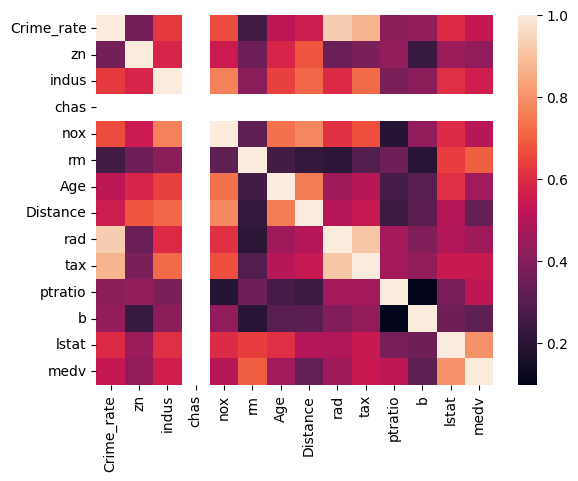

In [10]:
sns.heatmap(abs(corr))

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

x = data[[q for q in data if not q=="medv"]]
y = data["medv"]

In [14]:
l = LinearRegression()
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2)
l.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
l.score(xtest, ytest)

0.7045064347724911

In [17]:
ypred=l.predict(xtest)

In [19]:
metrics.mean_squared_error(ytest, ypred)

15.503070046108656